<a href="https://colab.research.google.com/github/sourina/Assigment-Bonz.ai/blob/main/smartphone_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Project: Predicting Dominant App Usage Type from Smartphone Behaviour

**Dataset:** [Smartphone Usage and Behavioral Dataset](https://www.kaggle.com/datasets/bhadramohit/smartphone-usage-and-behavioral-dataset)  
**File:** `mobile_usage_behavioral_analysis.csv`

## What I'm trying to do

I want to predict which category of app a person uses most — Social Media, Gaming, or Productivity — using only general behaviour data like total screen time, age, number of apps, and location. The dataset has per-category hours but I removed those from the features after using them to create the target label. The idea is to make the model work from indirect signals, which is more realistic.

**Task type:** Multi-class classification (3 classes)

---
## Setup — Download Dataset from Kaggle

Run once and upload kaggle.json when it asks.

In [2]:
import os
!pip install kaggle --quiet

from google.colab import files
print("Upload your kaggle.json:")
files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d bhadramohit/smartphone-usage-and-behavioral-dataset --unzip
!ls *.csv

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bhadramohit/smartphone-usage-and-behavioral-dataset
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 16.7k/16.7k [00:00<00:00, 28.6MB/s]

mobile_usage_behavioral_analysis.csv


---
## Step 1: Load and Look at the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [4]:
df = pd.read_csv('mobile_usage_behavioral_analysis.csv')
print(df.shape)
df.head()

(1000, 10)


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


In [6]:
df.describe()

,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000


In [7]:
# check for missing values
print(df.isnull().sum())
# all zeros, dataset is clean

User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64


---
## Step 2: Create the Target Label + Prepare Features

No target column in the raw data. I assigned each user a label based on which of the three category columns was highest. Then dropped those columns so the model can't just look at them directly.

In [8]:
usage_cols = {
    'Social_Media_Usage_Hours': 'Social Media',
    'Gaming_App_Usage_Hours': 'Gaming',
    'Productivity_App_Usage_Hours': 'Productivity'
}

df['label'] = df[list(usage_cols.keys())].idxmax(axis=1).map(usage_cols)

print(df['label'].value_counts())
# pretty balanced which is good

label
Productivity    349
Social Media    338
Gaming          313
Name: count, dtype: int64


In [9]:
drop_cols = ['User_ID', 'Social_Media_Usage_Hours', 'Gaming_App_Usage_Hours', 'Productivity_App_Usage_Hours']
data = df.drop(columns=drop_cols).copy()

# double checking no missing after drop
# data.dropna(inplace=True)  # didn't need this
print('missing:', data.isnull().sum().sum())
print('features:', [c for c in data.columns if c != 'label'])

missing: 0
features: ['Age', 'Gender', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 'Number_of_Apps_Used', 'Location']


In [10]:
# one-hot encode Gender and Location
# drop_first=True to avoid dummy variable trap
data = pd.get_dummies(data, columns=['Gender', 'Location'], drop_first=True)

le = LabelEncoder()
y = le.fit_transform(data['label'])
X = data.drop(columns=['label'])

print('classes:', list(le.classes_))
print('X shape:', X.shape)

classes: ['Gaming', 'Productivity', 'Social Media']
X shape: (1000, 9)


In [11]:
# scale numeric features
num_cols = ['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 'Number_of_Apps_Used']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X.head()

,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Gender_Male,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,1.416592,-1.211402,-0.147161,0.965493,True,False,True,False,False
1,0.595617,-1.364596,1.641473,0.177657,True,False,False,False,False
2,-0.553748,0.279046,-0.860998,-0.741485,False,True,False,False,False
3,-1.128430,-1.661408,-0.378821,0.571575,False,False,False,False,True
4,-0.061163,-0.030533,1.318226,-0.347567,True,False,False,True,False


---
## Step 3: Visualizations

Wanted to see the class distribution, if usage hours differ by type, age spread, and feature correlations.

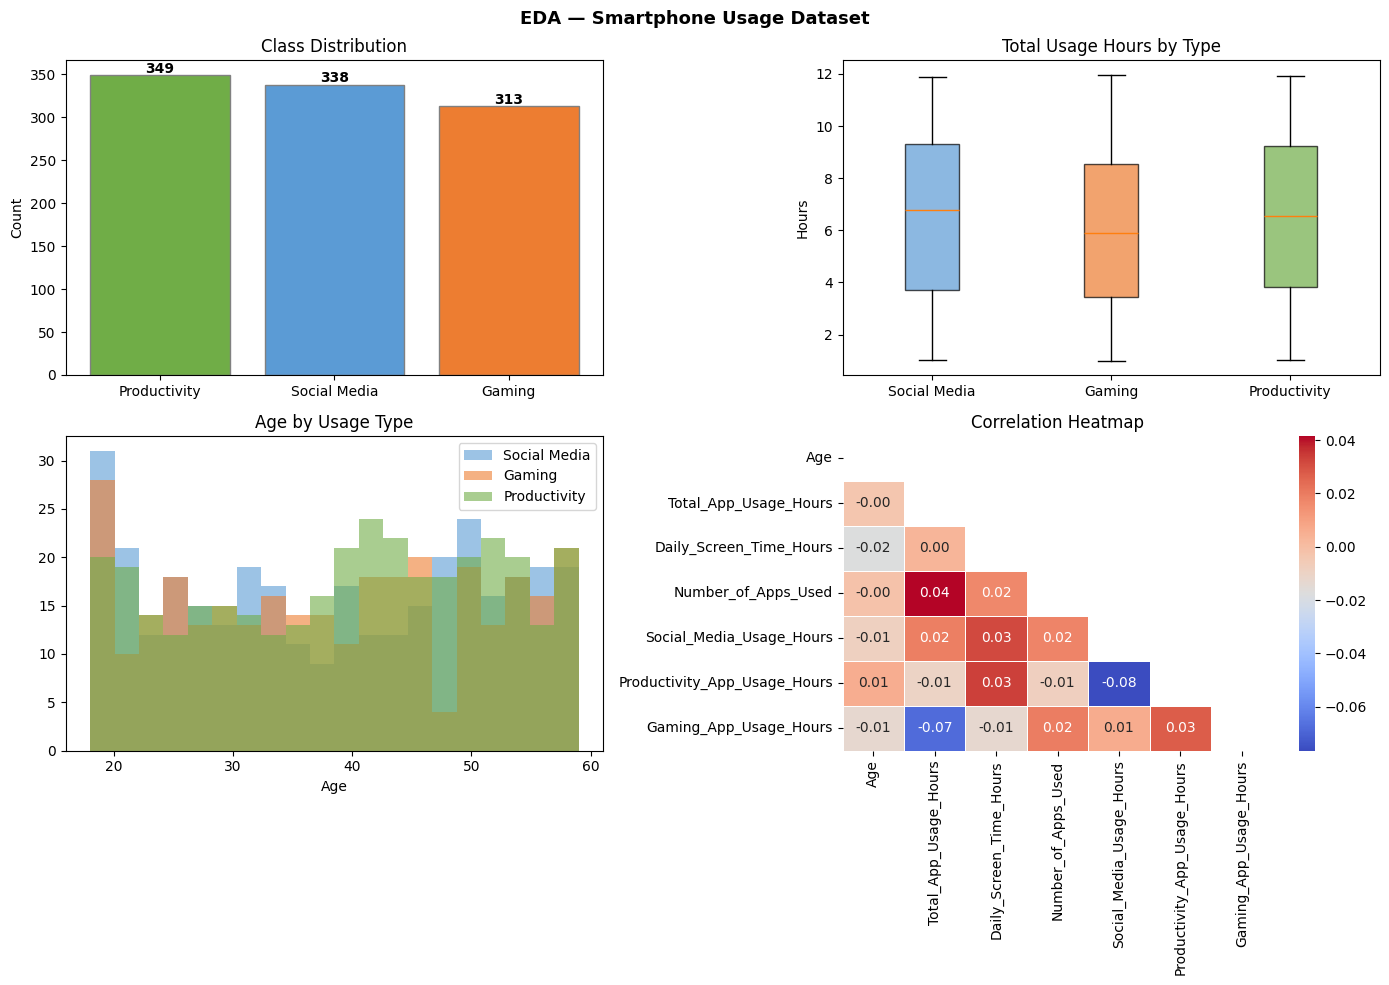

In [12]:
palette = {'Social Media': '#5B9BD5', 'Gaming': '#ED7D31', 'Productivity': '#70AD47'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Smartphone Usage Dataset', fontsize=13, fontweight='bold')

# class counts
class_counts = df['label'].value_counts()
bars = axes[0, 0].bar(class_counts.index, class_counts.values,
                       color=[palette[c] for c in class_counts.index], edgecolor='grey')
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Count')
for bar, v in zip(bars, class_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 3, str(v), ha='center', fontweight='bold')

# usage hours by type
groups = [df[df['label'] == c]['Total_App_Usage_Hours'].values for c in palette]
bp = axes[0, 1].boxplot(groups, labels=list(palette.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], palette.values()):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0, 1].set_title('Total Usage Hours by Type')
axes[0, 1].set_ylabel('Hours')

# age by type
for label, color in palette.items():
    axes[1, 0].hist(df[df['label'] == label]['Age'], bins=20, alpha=0.6, label=label, color=color)
axes[1, 0].set_title('Age by Usage Type')
axes[1, 0].set_xlabel('Age')
axes[1, 0].legend()

# correlation heatmap
num_df = df.select_dtypes(include='number').drop(columns=['User_ID'])
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=np.triu(np.ones_like(num_df.corr(), dtype=bool)),
            linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

From the plots — the classes are pretty balanced, which is good. But the total usage hours and age distributions overlap a lot across all three types. That's already a sign the model might struggle.

---
## Step 4: Train the Model

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 800, Test: 200


In [14]:
# tried n_estimators=50 first but 100 gave slightly more stable results
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)
print('done')

done


Daily_Screen_Time_Hours    0.243980
Total_App_Usage_Hours      0.243118
Age                        0.196124
Number_of_Apps_Used        0.185767
Gender_Male                0.034514
Location_New York          0.026994
Location_Los Angeles       0.023616
Location_Houston           0.023171
Location_Phoenix           0.022717
dtype: float64


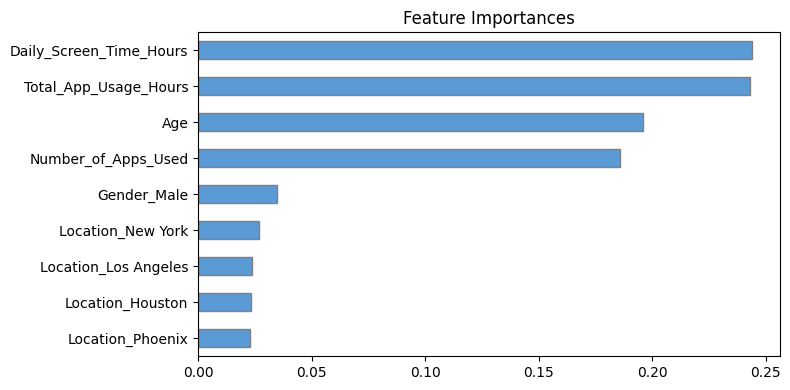

In [15]:
# feature importances
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_imp)

feat_imp.plot(kind='barh', figsize=(8, 4), color='#5B9BD5', edgecolor='grey')
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.tight_layout()
plt.show()
# screen time and total usage are top, location barely does anything

---
## Step 5: Evaluate

In [16]:
y_pred = model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1       : {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy : 0.3550
Precision: 0.3509
Recall   : 0.3525
F1       : 0.3505

              precision    recall  f1-score   support

      Gaming       0.31      0.25      0.28        63
Productivity       0.35      0.39      0.37        70
Social Media       0.39      0.42      0.41        67

    accuracy                           0.35       200
   macro avg       0.35      0.35      0.35       200
weighted avg       0.35      0.35      0.35       200



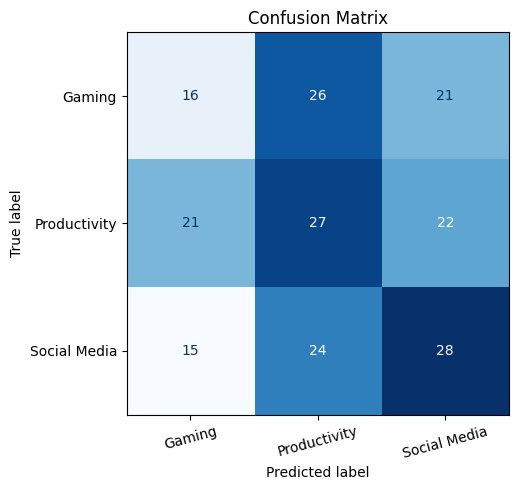

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## Step 6: Notes on Results

35.5% accuracy — which is honestly pretty close to just guessing (random would be ~33%). I expected it to be low after removing the per-category columns but not quite this low.

Looking at the confusion matrix, gaming gets misclassified the most. Social Media was slightly easier to predict (F1 = 0.41).

The feature importances make sense though — screen time and total usage hours carry most of the signal, and location/gender barely help. The problem is that even those top features are ambiguous: high screen time could mean gaming or social media.

Things I'd try next time:
- Create a ratio feature like screen_time / num_apps — might separate user types better
- Try gradient boosting instead of random forest
- Tune max_depth with cross-validation to reduce overfitting